In [8]:
import json

with open("../data/SNOWPACK/vstations.json") as f:
    stations = json.load(f)

print(stations.keys())

dict_keys(['VIR1A', 'VIR2A', 'VIR3A', 'VIR4A', 'VIR5A', 'VIR6A', 'VIR7A', 'VIR8A', 'VIR9A', 'VIR10A', 'VIR11A', 'VIR12A', 'VIR13A', 'VIR14A', 'VIR15A', 'VIR16A', 'VIR17A', 'VIR18A', 'VIR19A', 'VIR20A', 'VIR21A', 'VIR22A', 'VIR23A', 'VIR24A', 'VIR25A', 'VIR26A', 'VIR27A', 'VIR28A', 'VIR29A', 'VIR30A', 'VIR31A', 'VIR32A', 'VIR33A', 'VIR34A', 'VIR35A', 'VIR36A', 'VIR37A', 'VIR38A', 'VIR39A', 'VIR40A', 'VIR41A', 'VIR42A', 'VIR43A', 'VIR44A', 'VIR45A', 'VIR46A', 'VIR47A', 'VIR48A', 'VIR49A', 'VIR50A', 'VIR51A', 'VIR52A', 'VIR53A', 'VIR54A', 'VIR55A', 'VIR56A', 'VIR57A', 'VIR58A', 'VIR59A', 'VIR60A', 'VIR61A', 'VIR62A', 'VIR63A', 'VIR64A', 'VIR65A', 'VIR66A', 'VIR67A', 'VIR68A', 'VIR69A', 'VIR70A', 'VIR71A', 'VIR72A', 'VIR73A', 'VIR74A', 'VIR75A', 'VIR76A', 'VIR77A', 'VIR78A', 'VIR79A', 'VIR80A', 'VIR81A', 'VIR82A', 'VIR83A', 'VIR84A', 'VIR85A', 'VIR86A', 'VIR87A', 'VIR88A', 'VIR89A', 'VIR90A', 'VIR91A', 'VIR92A', 'VIR93A', 'VIR94A', 'VIR95A', 'VIR96A', 'VIR97A', 'VIR98A', 'VIR99A', 'VIR100A

In [12]:
import pandas as pd

file = "../data/SNOWPACK/smet/VIR1A.smet"

# Les fila som ren tekst
with open(file, "r") as f:
    lines = f.readlines()

# Finn feltnavn fra header
fields_line = [line for line in lines if line.startswith("fields")][0]
colnames = fields_line.split("=", 1)[1].strip().split()

# Finn hvor data starter
data_start = [i for i, line in enumerate(lines) if line.strip() == "[DATA]"][0] + 1

# Les data
df = pd.read_csv(
    file,
    sep=r"\s+",
    skiprows=data_start,
    names=colnames,
    na_values=-999
)

# Konverter tid
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,timestamp,Qs,Ql,Qg,TSG,Qg0,Qr,dIntEnergySnow,meltFreezeEnergySnow,ColdContentSnow,...,zSd,Sd,zSn,Sn,zSs,Ss,zS4,S4,zS5,S5
0,2024-09-01 01:00:00,1.818,0.419,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,6.0,0.0,6.0,0.0,6.0,0.0,6.0,0.0,NaN
1,2024-09-01 02:00:00,2.454,0.437,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,6.0,0.0,6.0,0.0,6.0,0.0,6.0,0.0,NaN
2,2024-09-01 03:00:00,8.248,0.783,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,6.0,0.0,6.0,0.0,6.0,0.0,6.0,0.0,NaN
3,2024-09-01 04:00:00,18.528,1.816,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,6.0,0.0,6.0,0.0,6.0,0.0,6.0,0.0,NaN
4,2024-09-01 05:00:00,13.223,1.542,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,6.0,0.0,6.0,0.0,6.0,0.0,6.0,0.0,NaN


In [14]:
print(df.columns.tolist())

['timestamp', 'Qs', 'Ql', 'Qg', 'TSG', 'Qg0', 'Qr', 'dIntEnergySnow', 'meltFreezeEnergySnow', 'ColdContentSnow', 'OLWR', 'ILWR', 'LWR_net', 'RSWR', 'ISWR', 'Qw', 'pAlbedo', 'mAlbedo', 'ISWR_h', 'ISWR_dir', 'ISWR_diff', 'TA', 'TSS_mod', 'TSS_meas', 'T_bottom', 'RH', 'VW', 'VW_drift', 'DW', 'MS_Snow', 'HS_mod', 'HS_meas', 'hoar_size', 'wind_trans24', 'HN3', 'HN6', 'HN12', 'HN24', 'HN72_24', 'HNW24', 'ski_pen', 'SWE', 'MS_Water', 'MS_Water_Soil', 'MS_Ice_Soil', 'MS_Wind', 'MS_Rain', 'MS_SN_Runoff', 'MS_Surface_Mass_Flux', 'MS_Soil_Runoff', 'MS_Sublimation', 'MS_Evap', 'Sclass1', 'Sclass2', 'zSd', 'Sd', 'zSn', 'Sn', 'zSs', 'Ss', 'zS4', 'S4', 'zS5', 'S5']


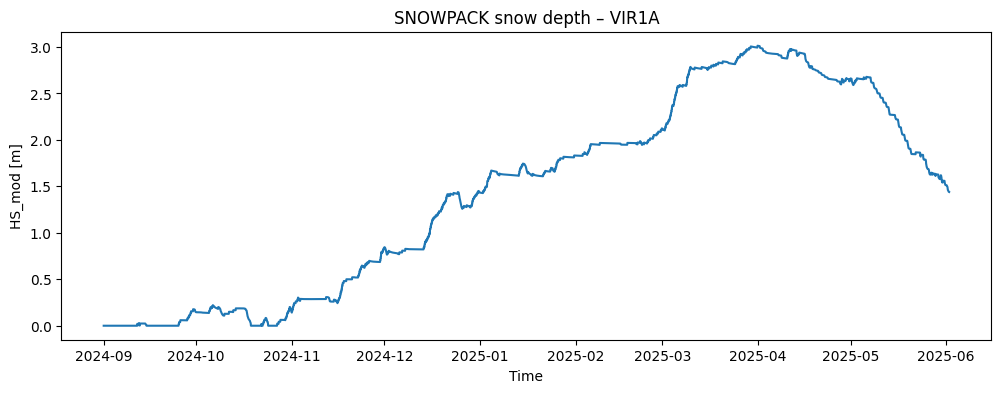

In [17]:
import matplotlib.pyplot as plt

df["HS_mod_m"] = df["HS_mod"] / 100

plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["HS_mod_m"])
plt.title("SNOWPACK snow depth – VIR1A")
plt.ylabel("HS_mod [m]")
plt.xlabel("Time")
plt.show()

In [18]:
print(df[["timestamp", "HS_mod", "SWE"]].head())
print(df[["HS_mod", "SWE"]].describe())

            timestamp  HS_mod  SWE
0 2024-09-01 01:00:00     0.0  0.0
1 2024-09-01 02:00:00     0.0  0.0
2 2024-09-01 03:00:00     0.0  0.0
3 2024-09-01 04:00:00     0.0  0.0
4 2024-09-01 05:00:00     0.0  0.0
            HS_mod          SWE
count  6575.000000  6575.000000
mean    143.826349   667.155301
std     103.571762   498.227142
min       0.000000     0.000000
25%      28.636000   116.896000
50%     162.653000   755.343000
75%     240.124500  1171.564500
max     301.418000  1383.165000
